Prueba

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
import random


LEER DATASET

In [3]:
import pandas as pd

datosMLP = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_mlp_pollution.csv")
datosLSTM = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_lstm_pollution.csv")
datosGRU = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_gru_pollution.csv")

datosMLP['date'] = pd.to_datetime(datosMLP['date'])
datosLSTM['date'] = pd.to_datetime(datosLSTM['date'])
datosGRU['date'] = pd.to_datetime(datosGRU['date'])

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)
datosLSTM.set_index('date', inplace=True)
datosGRU.set_index('date', inplace=True)


In [4]:
datosMLP.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,e
date,,,,,,,
2014-12-31 19:00:00,-1.009952,-1.702068,-1.106944,1.679851,0.694538,4.054828,-0.056149
2014-12-31 20:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.168890,0.005569
2014-12-31 21:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.265479,-0.029062
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.035766
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,0.032112


In [5]:
datosLSTM.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,e
date,,,,,,,
2014-12-31 19:00:00,-1.009952,-1.702068,-1.106944,1.679851,0.694538,4.054828,-0.017564
2014-12-31 20:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.168890,0.038002
2014-12-31 21:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.265479,0.018046
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.007399
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,0.049547


In [6]:
datosGRU.tail()

,pollution,dew,temp,press,wnd_dir,wnd_spd,e
date,,,,,,,
2014-12-31 19:00:00,-1.009952,-1.702068,-1.106944,1.679851,0.694538,4.054828,-0.032836
2014-12-31 20:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.168890,0.021897
2014-12-31 21:00:00,-0.988008,-1.632347,-1.187734,1.679851,0.694538,4.265479,-0.001082
2014-12-31 22:00:00,-1.009952,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.021268
2014-12-31 23:00:00,-0.966063,-1.562627,-1.187734,1.679851,0.694538,4.405847,0.039714


In [7]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe MLP input es un tipo de dato: ", datosMLP.index.dtype)
print("El index del dataframe LSTM input es un tipo de dato: ", datosLSTM.index.dtype)
print("El index del dataframe GRU input es un tipo de dato: ", datosGRU.index.dtype)


El index del dataframe MLP input es un tipo de dato:  datetime64[ns]
El index del dataframe LSTM input es un tipo de dato:  datetime64[ns]
El index del dataframe GRU input es un tipo de dato:  datetime64[ns]


Se establece el formato de datos de entrada para redes GRU y LSTM, es decir [observaciones, retardos, caracteristicas]

In [8]:
futuros = 1
pasados  = 12

In [9]:
datosMLPX = []
datosMLPY = []
for i in range(pasados, len(datosMLP) - futuros + 1):
  datosMLPX.append(datosMLP.iloc[i-pasados:i, 0:datosMLP.shape[1]])
  datosMLPY.append(datosMLP.iloc[i+futuros-1:i+futuros, 0])


In [10]:
datosLSTMX = []
datosLSTMY = []
for i in range(pasados, len(datosLSTM) - futuros + 1):
  datosLSTMX.append(datosLSTM.iloc[i-pasados:i, 0:datosLSTM.shape[1]])
  datosLSTMY.append(datosLSTM.iloc[i+futuros-1:i+futuros, 0])

In [11]:
datosGRUX = []
datosGRUY = []
for i in range(pasados, len(datosGRU) - futuros + 1):
  datosGRUX.append(datosGRU.iloc[i-pasados:i, 0:datosGRU.shape[1]])
  datosGRUY.append(datosGRU.iloc[i+futuros-1:i+futuros, 0])

In [12]:
# Convertir las listas en arrays numpy
datosMLPX = np.array(datosMLPX)
datosMLPY = np.array(datosMLPY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de MLP X:", datosMLPX.shape)  
print("Dimensiones de MLP Y:", datosMLPY.shape)  

Dimensiones de MLP X: (43788, 12, 7)
Dimensiones de MLP Y: (43788, 1)


In [13]:
# Convertir las listas en arrays numpy
datosLSTMX = np.array(datosLSTMX)
datosLSTMY = np.array(datosLSTMY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de LSTM X:", datosLSTMX.shape)  
print("Dimensiones de LSTM Y:", datosLSTMY.shape)  

Dimensiones de LSTM X: (43788, 12, 7)
Dimensiones de LSTM Y: (43788, 1)


In [14]:
# Convertir las listas en arrays numpy
datosGRUX = np.array(datosGRUX)
datosGRUY = np.array(datosGRUY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de GRU X:", datosGRUX.shape)  
print("Dimensiones de GRU Y:", datosGRUY.shape)  

Dimensiones de GRU X: (43788, 12, 7)
Dimensiones de GRU Y: (43788, 1)


In [15]:
inputs = datosMLPX.shape[1] * datosMLPX.shape[2]
datosMLPX = datosMLPX.reshape(datosMLPX.shape[0], inputs)

In [16]:
datosMLPX

array([[ 3.17680987e-01, -1.21402290e+00, -1.26852411e+00, ...,
        -3.80943830e-01, -9.55565742e-02,             nan],
       [ 5.26152265e-01, -1.14430217e+00, -1.26852411e+00, ...,
        -3.80943830e-01, -3.41086545e-02,  4.33933430e-04],
       [ 6.46846163e-01, -8.65419279e-01, -1.34931411e+00, ...,
        -3.80943830e-01,  4.48116768e-02,  2.38536586e-01],
       ...,
       [-1.00995189e+00, -1.63234723e+00, -1.18773412e+00, ...,
         6.94538475e-01,  4.16888979e+00,  5.56898183e-03],
       [-1.02092406e+00, -1.63234723e+00, -1.10694413e+00, ...,
         6.94538475e-01,  4.26547885e+00, -2.90622705e-02],
       [-9.66063200e-01, -1.63234723e+00, -1.10694413e+00, ...,
         6.94538475e-01,  4.34439918e+00, -3.57658271e-02]])

Se dividen nuevamente los conjuntos de datos

In [17]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainMLPX, testMLPX = train_test_split(datosMLPX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testMLPX, valMLPX = train_test_split(testMLPX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainMLPX son: ", trainMLPX.shape)
print("Las dimensiones de testMLPX son: ", testMLPX.shape)
print("Las dimensiones de valMLPX son: ", valMLPX.shape)


Las dimensiones de trainMLPX son:  (30651, 84)
Las dimensiones de testMLPX son:  (8801, 84)
Las dimensiones de valMLPX son:  (4336, 84)


In [18]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainLSTMX, testLSTMX = train_test_split(datosLSTMX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testLSTMX, valLSTMX = train_test_split(testLSTMX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainLSTMX son: ", trainLSTMX.shape)
print("Las dimensiones de testLSTMX son: ", testLSTMX.shape)
print("Las dimensiones de valLSTMX son: ", valLSTMX.shape)

Las dimensiones de trainLSTMX son:  (30651, 12, 7)
Las dimensiones de testLSTMX son:  (8801, 12, 7)
Las dimensiones de valLSTMX son:  (4336, 12, 7)


In [19]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainGRUX, testGRUX = train_test_split(datosGRUX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testGRUX, valGRUX = train_test_split(testGRUX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainGRUX son: ", trainGRUX.shape)
print("Las dimensiones de testGRUX son: ", testGRUX.shape)
print("Las dimensiones de valGRUX son: ", valGRUX.shape)

Las dimensiones de trainGRUX son:  (30651, 12, 7)
Las dimensiones de testGRUX son:  (8801, 12, 7)
Las dimensiones de valGRUX son:  (4336, 12, 7)


In [20]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainY, testY = train_test_split(datosMLPY, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testY, valY = train_test_split(testY, test_size=0.33, shuffle=False)

print("Las dimensiones de trainY son: ", trainY.shape)
print("Las dimensiones de testY son: ", testY.shape)
print("Las dimensiones de valY son: ", valY.shape)

Las dimensiones de trainY son:  (30651, 1)
Las dimensiones de testY son:  (8801, 1)
Las dimensiones de valY son:  (4336, 1)


Se crean métricas para medir desempeño

In [21]:
import tensorflow.keras.backend as K

def smape(y_true, y_pred):
    """
    Define la función SMAPE (Error Porcentual Absoluto Medio Simétrico).
    """
    summ = K.abs(y_true) + K.abs(y_pred)
    smape_val = K.abs(y_pred - y_true) / summ * 2.0
    return K.mean(smape_val, axis=-1)

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def ia(y_true, y_pred):
    numerator = K.sum(K.abs(y_true - y_pred))
    denominator = K.sum(K.abs(y_true - K.mean(y_true)) + K.abs(y_pred - K.mean(y_true)))
    return 1 - (numerator / denominator)

Se define el index del conjunto de validación para utilizarlo posteriormente para graficar.

In [22]:
# Fecha y hora de término del conjunto de datos de prueba
end_date = datosMLP.index[-1]
n_observations = valY.shape[0]  # Cambia esto al número de observaciones en tu conjunto de prueba

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(hours = (n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='1H')

val_date

C:\Users\wamt1\AppData\Local\Temp\ipykernel_19432\196214621.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='1H')


DatetimeIndex(['2014-07-04 08:00:00', '2014-07-04 09:00:00',
               '2014-07-04 10:00:00', '2014-07-04 11:00:00',
               '2014-07-04 12:00:00', '2014-07-04 13:00:00',
               '2014-07-04 14:00:00', '2014-07-04 15:00:00',
               '2014-07-04 16:00:00', '2014-07-04 17:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', length=4336, freq='h')

Se guardan los índices de las observaciones a utilizar para predecir

In [23]:
indices = []
for i in range(pasados, len(datosMLP) - futuros + 1):
  indices.append(datosMLP.index[i+futuros-2])

# Modelos


## MLP

In [23]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [24]:
modelMLP = Sequential()
modelMLP.add(InputLayer(input_shape=(testMLPX.shape[1],)))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(1))

opt = Adam(learning_rate=0.00027101707182655693)

modelMLP.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelMLP.summary()








c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,545 (236.50 KB)

 Trainable params: 60,545 (236.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyMLP = modelMLP.fit(testMLPX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionMLP = modelMLP.predict(valMLPX)


Epoch 1/128
385/385 - 4s - 10ms/step - ia: 0.8353 - loss: 0.1504 - mae: 0.2339 - rmse: 0.3231 - smape: 0.4884 - val_ia: 0.6096 - val_loss: 0.0678 - val_mae: 0.1526 - val_rmse: 0.2039 - val_smape: 0.4673
Epoch 2/128
385/385 - 1s - 3ms/step - ia: 0.8697 - loss: 0.0789 - mae: 0.1841 - rmse: 0.2589 - smape: 0.4210 - val_ia: 0.6155 - val_loss: 0.0669 - val_mae: 0.1502 - val_rmse: 0.2001 - val_smape: 0.4620
Epoch 3/128
385/385 - 1s - 3ms/step - ia: 0.8740 - loss: 0.0749 - mae: 0.1778 - rmse: 0.2515 - smape: 0.4086 - val_ia: 0.6112 - val_loss: 0.0679 - val_mae: 0.1525 - val_rmse: 0.2027 - val_smape: 0.4657
Epoch 4/128
385/385 - 1s - 3ms/step - ia: 0.8763 - loss: 0.0730 - mae: 0.1744 - rmse: 0.2478 - smape: 0.3994 - val_ia: 0.6125 - val_loss: 0.0677 - val_mae: 0.1518 - val_rmse: 0.2022 - val_smape: 0.4643
Epoch 5/128
385/385 - 1s - 3ms/step - ia: 0.8798 - loss: 0.0702 - mae: 0.1697 - rmse: 0.2423 - smape: 0.3924 - val_ia: 0.6121 - val_loss: 0.0674 - val_mae: 0.1516 - val_rmse: 0.2014 - val_sma

In [26]:
metricasMLP = modelMLP.evaluate(valMLPX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasMLP}")

136/136 - 0s - 2ms/step - ia: 0.7577 - loss: 0.0397 - mae: 0.1242 - rmse: 0.1768 - smape: 0.3303
Métricas en el conjunto de validación: [0.03969357907772064, 0.12421901524066925, 0.33030965924263, 0.17680342495441437, 0.7576895356178284]


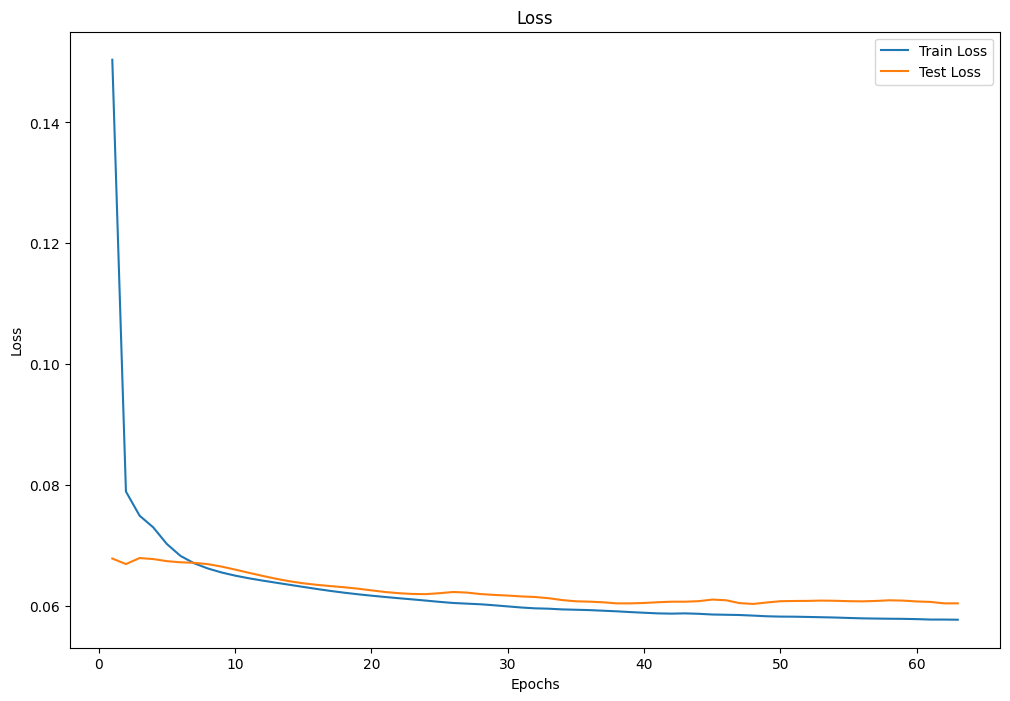

In [27]:
historyMLP = historyMLP.history

ejeXMLP = range(1, len(historyMLP['loss']) + 1)

plt.figure(figsize=(12, 8))
plt.plot(ejeXMLP, historyMLP['loss'], label='Train Loss')
plt.plot(ejeXMLP, historyMLP['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyMLP['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyMLP['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.05768067017197609
Último valor de Test Loss: 0.06039160490036011


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionMLP.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfMLP = df
fig.show()

In [30]:
dfMLP.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\1pasos_mlp_pollution.csv', index=True)

In [31]:
modelMLP.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\1pasos_mlp_pollution.h5')

## LSTM

In [24]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [25]:
modelLSTM = Sequential()
modelLSTM.add(InputLayer(input_shape=(testLSTMX.shape[1], testLSTMX.shape[2])))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=False))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(Dense(1))


opt = Adam(learning_rate=0.00027101707182655693)
modelLSTM.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelLSTM.summary()



c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 464,513 (1.77 MB)

 Trainable params: 464,513 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyLSTM = modelLSTM.fit(testLSTMX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionLSTM = modelLSTM.predict(valLSTMX)

Epoch 1/128
385/385 - 14s - 37ms/step - ia: 0.6657 - loss: 0.3939 - mae: 0.4288 - rmse: 0.5907 - smape: 0.8348 - val_ia: 0.3112 - val_loss: 0.1867 - val_mae: 0.3214 - val_rmse: 0.3837 - val_smape: 0.8533
Epoch 2/128
385/385 - 11s - 28ms/step - ia: 0.7957 - loss: 0.1657 - mae: 0.2749 - rmse: 0.3800 - smape: 0.6003 - val_ia: 0.4539 - val_loss: 0.0997 - val_mae: 0.2192 - val_rmse: 0.2767 - val_smape: 0.6425
Epoch 3/128
385/385 - 10s - 25ms/step - ia: 0.8572 - loss: 0.0947 - mae: 0.1985 - rmse: 0.2815 - smape: 0.4583 - val_ia: 0.5820 - val_loss: 0.0674 - val_mae: 0.1617 - val_rmse: 0.2165 - val_smape: 0.5048
Epoch 4/128
385/385 - 8s - 22ms/step - ia: 0.8836 - loss: 0.0689 - mae: 0.1643 - rmse: 0.2388 - smape: 0.3885 - val_ia: 0.6170 - val_loss: 0.0640 - val_mae: 0.1456 - val_rmse: 0.1993 - val_smape: 0.4635
Epoch 5/128
385/385 - 8s - 20ms/step - ia: 0.8903 - loss: 0.0641 - mae: 0.1553 - rmse: 0.2292 - smape: 0.3701 - val_ia: 0.6286 - val_loss: 0.0624 - val_mae: 0.1404 - val_rmse: 0.1931 - 

In [27]:
metricasLSTM = modelLSTM.evaluate(valLSTMX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasLSTM}")

136/136 - 2s - 12ms/step - ia: 0.7826 - loss: 0.0384 - mae: 0.1157 - rmse: 0.1701 - smape: 0.3137
Métricas en el conjunto de validación: [0.03844371438026428, 0.11569307744503021, 0.3136802613735199, 0.17009104788303375, 0.7826391458511353]


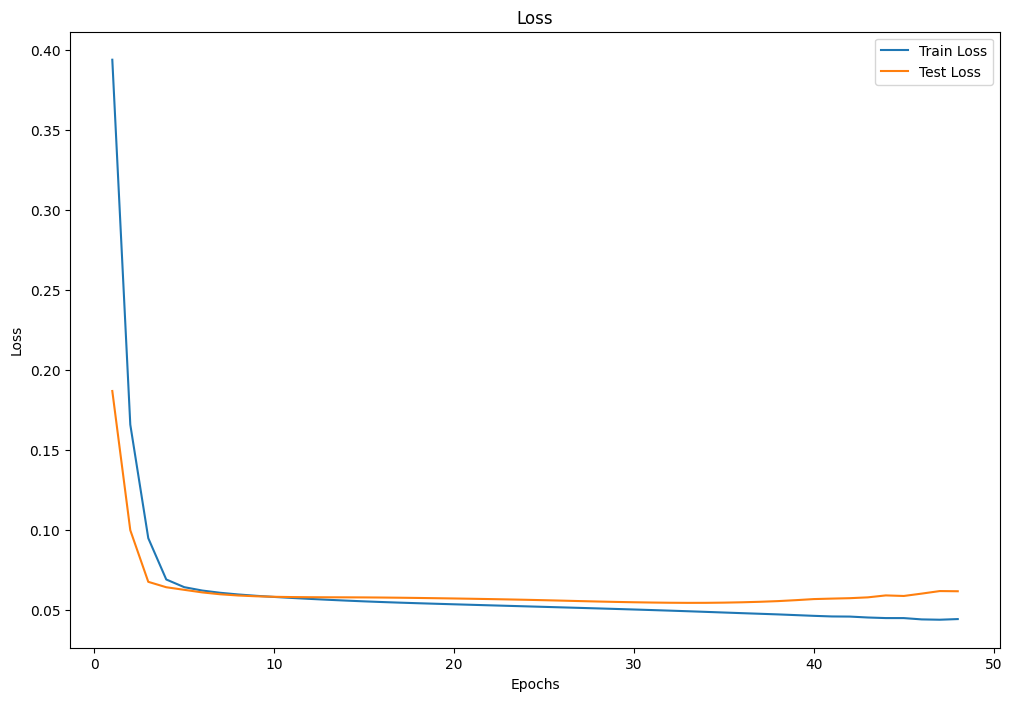

In [28]:
historyLSTM = historyLSTM.history

ejeXLSTM = range(1, len(historyLSTM['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXLSTM, historyLSTM['loss'], label='Train Loss')
plt.plot(ejeXLSTM, historyLSTM['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [29]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyLSTM['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyLSTM['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.044138871133327484
Último valor de Test Loss: 0.06153396517038345


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionLSTM.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfLSTM = df
fig.show()


In [31]:
dfLSTM.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\1pasos_lstm_pollution.csv', index=True)

In [32]:
modelLSTM.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\1pasos_lstm_pollution.h5')

## GRU

In [41]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [42]:
modelGRU = Sequential()
modelGRU.add(InputLayer(input_shape=(testGRUX.shape[1], testGRUX.shape[2])))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=False))
modelGRU.add(Dropout(0.0))

modelGRU.add(Dense(1))


opt = Adam(learning_rate=0.00027101707182655693)
modelGRU.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelGRU.summary()




c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 128)        │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,953 (1.33 MB)

 Trainable params: 349,953 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyGRU = modelGRU.fit(testGRUX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionGRU = modelGRU.predict(valGRUX)

Epoch 1/128
385/385 - 13s - 34ms/step - ia: 0.8060 - loss: 0.1602 - mae: 0.2601 - rmse: 0.3601 - smape: 0.5631 - val_ia: 0.5512 - val_loss: 0.0723 - val_mae: 0.1714 - val_rmse: 0.2245 - val_smape: 0.5298
Epoch 2/128
385/385 - 6s - 15ms/step - ia: 0.8793 - loss: 0.0749 - mae: 0.1690 - rmse: 0.2468 - smape: 0.3972 - val_ia: 0.6053 - val_loss: 0.0623 - val_mae: 0.1501 - val_rmse: 0.2032 - val_smape: 0.4734
Epoch 3/128
385/385 - 6s - 15ms/step - ia: 0.8904 - loss: 0.0647 - mae: 0.1546 - rmse: 0.2299 - smape: 0.3659 - val_ia: 0.6230 - val_loss: 0.0594 - val_mae: 0.1423 - val_rmse: 0.1946 - val_smape: 0.4542
Epoch 4/128
385/385 - 6s - 15ms/step - ia: 0.8939 - loss: 0.0619 - mae: 0.1500 - rmse: 0.2246 - smape: 0.3567 - val_ia: 0.6203 - val_loss: 0.0590 - val_mae: 0.1430 - val_rmse: 0.1948 - val_smape: 0.4554
Epoch 5/128
385/385 - 6s - 15ms/step - ia: 0.8957 - loss: 0.0605 - mae: 0.1475 - rmse: 0.2218 - smape: 0.3505 - val_ia: 0.6207 - val_loss: 0.0584 - val_mae: 0.1423 - val_rmse: 0.1935 - va

In [44]:
metricasGRU = modelGRU.evaluate(valGRUX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasGRU}")

136/136 - 1s - 7ms/step - ia: 0.7808 - loss: 0.0383 - mae: 0.1167 - rmse: 0.1702 - smape: 0.3179
Métricas en el conjunto de validación: [0.03834785893559456, 0.11665819585323334, 0.3178592622280121, 0.17023319005966187, 0.7807809710502625]


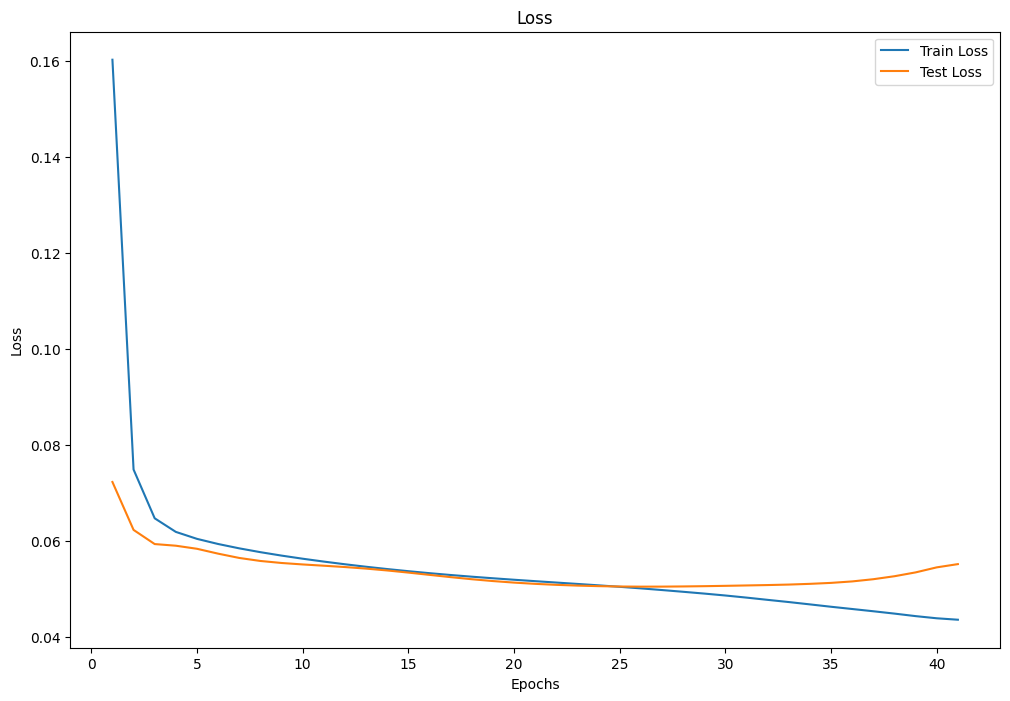

In [45]:
historyGRU = historyGRU.history

ejeXGRU = range(1, len(historyGRU['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXGRU, historyGRU['loss'], label='Train Loss')
plt.plot(ejeXGRU, historyGRU['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [46]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyGRU['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyGRU['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.04364084079861641
Último valor de Test Loss: 0.055214837193489075


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionGRU.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfGRU = df
fig.show()

In [48]:
dfGRU.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\1pasos_gru_pollution.csv', index=True)

In [49]:
modelGRU.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\1pasos_gru_pollution.h5')